# Consumer review EDA: Head & Shoulders, Pantene, Herbal Essences

Exploratory analysis of the cleaned Amazon Reviews 2023 corpus (Hou et al. 2024, arXiv:2403.03952), `Beauty_and_Personal_Care` category, filtered to three P&G haircare brands.

**Read every number here as a description of the sampled Amazon reviews, not of P&G's customers.** Amazon reviewers self-select, the dataset is a snapshot that ends on 2023-09-01, and some reviews come from incentivized programmes. Sentiment is VADER, a lexicon heuristic, not a trained model.

All aggregation lives in `src/eda.py` (cleaning in `src/clean.py`); this notebook only calls those functions, prints their output, and draws charts.

In [1]:
import sys
from pathlib import Path

# The notebook runs from notebooks/, so put the repo root on sys.path to import src.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src import config, eda

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 11, "axes.labelsize": 9,
                     "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8})
pd.set_option("display.width", 160)
pd.set_option("display.precision", 2)

## Data and cleaning rules

The corpus is built by two commands, which this notebook does not re-run:

```
uv run python data/download_data.py   # stream + filter the 11 GB / 2.8 GB source files
uv run python -m src.clean            # clean into data/processed/reviews_clean.parquet
```

Cleaning rules, as implemented in `data/download_data.py` and `src/clean.py`:

- **Brand match on `store` only.** A product belongs to a brand when its metadata `store` field matches that brand's pattern in `src/config.py`. Title-only matches are dropped because they are often third-party listings that merely name the brand.
- **Empty text dropped.** Reviews whose body is empty after whitespace normalization are removed.
- **Rating validated.** Ratings must be 1–5.
- **Duplicate `review_id` dropped.** The source has no review id, so one is derived by hashing user, product, timestamp, and body.
- **Copy-paste dedup.** Reviews whose casefolded, whitespace-collapsed text is at least 50 characters and already seen are dropped. Shorter texts ("Love it!") are kept, because identical short praise is genuine in a mostly five-star corpus.
- **Dates.** Epoch-millisecond timestamps are parsed as UTC; years outside 2000–2026 go to an `undated` bucket instead of being dropped.
- **Text kept intact.** `review_text` is byte-identical to the source for display and citation; `review_text_normalized` is a separate copy for embedding.

The first data cell fails with the two commands above if the parquet is missing.

In [2]:
reviews = eda.load_clean()
report = eda.load_report()

print(f"rows: {report['total_rows']:,} of {report['total_input']:,} input "
      f"({report['dropped_total']:,} dropped, {report['dropped_pct']}%)")
print("dropped by reason:")
for reason, drop in report["drops"].items():
    print(f"  {reason:<22} {drop['count']:>5,}  ({drop['pct']}%)")
print("rows per brand:", {b: f"{n:,}" for b, n in report["rows_per_brand"].items()})
print(f"date range: {report['date_range']['min'][:10]} to {report['date_range']['max'][:10]}")
print(f"undated rows: {eda.undated_count(reviews):,} (excluded from time series only)")
print(f"review length (chars): median {reviews['review_text'].str.len().median():.0f}, "
      f"p90 {reviews['review_text'].str.len().quantile(0.9):.0f}")
reviews.dtypes

rows: 53,872 of 54,741 input (869 dropped, 1.59%)
dropped by reason:
  no_brand_match             0  (0.0%)
  empty_text                43  (0.08%)
  invalid_rating             0  (0.0%)
  duplicate_review_id      456  (0.83%)
  duplicate_text           370  (0.68%)
rows per brand: {'Head & Shoulders': '9,363', 'Pantene': '28,977', 'Herbal Essences': '15,532'}
date range: 2005-01-05 to 2023-09-01
undated rows: 0 (excluded from time series only)
review length (chars): median 107, p90 457


review_id                                 str
brand                                     str
product_name                              str
rating                                  int64
review_title                              str
review_text                               str
review_text_normalized                    str
review_date               datetime64[us, UTC]
date_bucket                               str
verified                                 bool
dtype: object

## Chart 1: Rating distribution per brand

rating              1    2    3     4     5
brand                                      
Head & Shoulders  8.3  4.1  6.0  13.8  67.7
Pantene           8.5  4.2  6.2  11.7  69.4
Herbal Essences   8.7  5.0  7.4  13.0  65.9


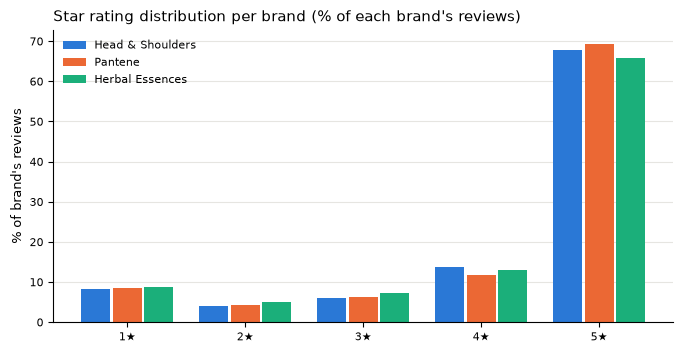

In [3]:
distribution = eda.rating_distribution(reviews)
print(distribution.round(1))

fig, ax = plt.subplots(figsize=(8, 3.8))
eda.plot_rating_distribution(ax, distribution)
ax.set_title("Star rating distribution per brand (% of each brand's reviews)", loc="left")
plt.show()

**Takeaway.** All three brands skew heavily five-star (65.9–69.4% of reviews) with a small one-star tail (8.3–8.7%), and the between-brand gaps are at most 3.5 points, so rating mix alone barely separates the brands. Herbal Essences has the largest 1–2★ share (13.7% vs 12.4% and 12.7%), a weak difference.

## Chart 2: Review volume over time per brand

brand  Head & Shoulders  Herbal Essences  Pantene
year                                             
2005                  1                4        8
2006                  0                4        2
2007                  4                2        7
2008                  1                3       11
2009                  7               16       38
2010                 16               27      188
2011                 35               65      171
2012                 91              111      314
2013                263              472     1150
2014                404              916     1527
2015               1231             2567     3438
2016                884             1665     2739
2017                671             1073     1936
2018                501              906     1617
2019                532             1308     2596
2020               1483             2179     4250
2021               1277             2049     3967
2022               1468             1621     3843


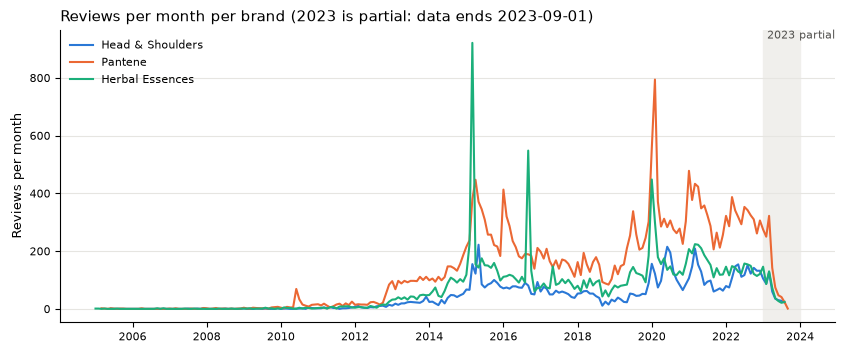

In [4]:
monthly = eda.monthly_stats(reviews)
yearly = eda.yearly_summary(reviews)
print(yearly.pivot(index="year", columns="brand", values="n_reviews").fillna(0).astype(int))
peaks = eda.peak_months(monthly)
print("\npeak month per brand:")
print(peaks.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 3.8))
eda.plot_monthly_volume(ax, monthly)
ax.set_title(f"Reviews per month per brand ({config.EDA_PARTIAL_YEAR} is partial: "
             f"data ends {report['date_range']['max'][:10]})", loc="left")
plt.show()

**Takeaway.** Volume is thin before 2013 (Pantene, the largest brand, has 314 reviews in all of 2012), and yearly counts peak in 2015 for Herbal Essences (2,567) and in 2020 for Head & Shoulders (1,483) and Pantene (4,250). The largest single month, Herbal Essences in March 2015 with 921 reviews, is about 4.3 times that brand's 2015 monthly average (2,567 / 12 = 214), a burst that may reflect a launch or review campaign, which this data cannot confirm.

## Chart 3: Average rating over time per brand

Months with fewer than `config.EDA_MIN_MONTH_REVIEWS` (30) reviews are drawn as faint dots and left out of the line, so a three-review month cannot swing the trend.

                  months  pct_months_small  pct_reviews_in_small
brand                                                           
Head & Shoulders     169              38.5                   6.9
Herbal Essences      183              31.7                   2.0
Pantene              196              33.2                   1.8

brand  Head & Shoulders  Herbal Essences  Pantene
year                                             
2013               4.40             4.29     4.30
2014               4.44             4.18     4.30
2015               4.49             4.25     4.44
2016               4.48             4.38     4.33
2017               4.33             4.30     4.32
2018               4.13             4.22     4.35
2019               4.36             4.32     4.43
2020               4.31             4.29     4.30
2021               4.17             4.06     4.23
2022               4.06             4.15     4.13
2023               4.20             4.00     4.19

monthly mean rating, mo

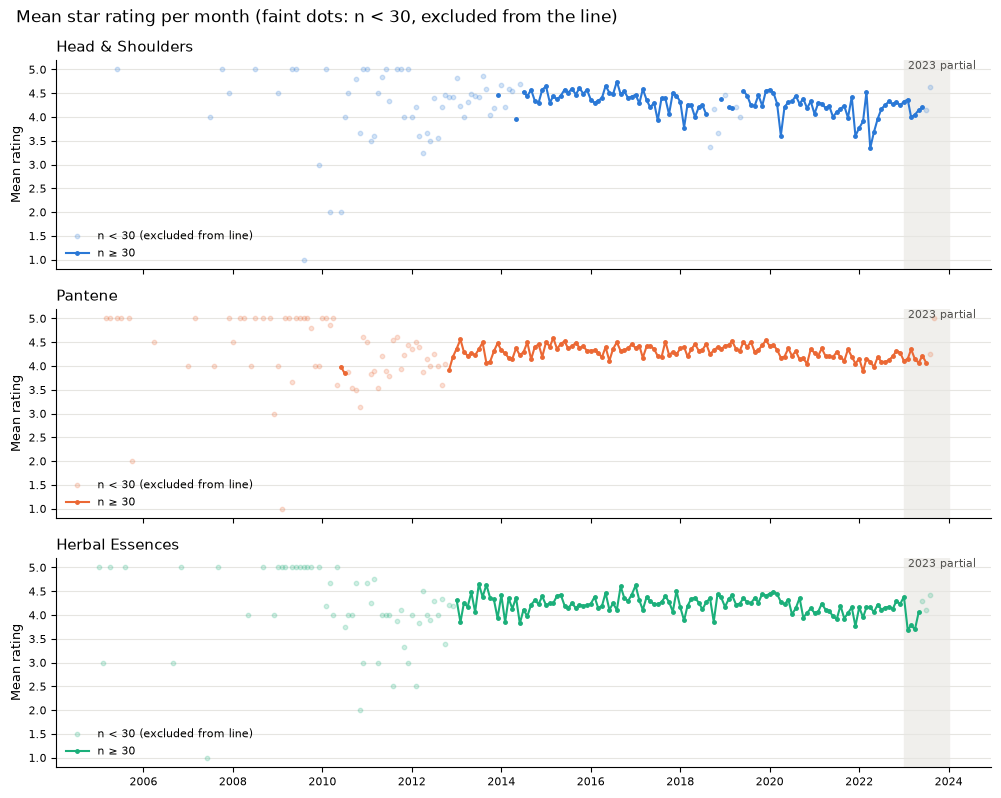

In [5]:
print(eda.small_sample_share(monthly).round(1))
print()
print(yearly.pivot(index="year", columns="brand", values="mean_rating").loc[2013:].round(2))
print(f"\nmonthly mean rating, months with n >= {config.EDA_MIN_MONTH_REVIEWS} only:")
print(eda.trend_summary(monthly).round(2))

brands = eda.brand_order(reviews)
fig, axes = plt.subplots(len(brands), 1, figsize=(10, 2.7 * len(brands)), sharex=True, squeeze=False)
for ax, brand in zip(axes[:, 0], brands):
    eda.plot_monthly_rating(ax, monthly, brand)
fig.suptitle(f"Mean star rating per month (faint dots: n < {config.EDA_MIN_MONTH_REVIEWS}, "
             "excluded from the line)", x=0.01, ha="left")
fig.tight_layout()
plt.show()

**Takeaway.** About a third of brand-months (31.7–38.5%) have fewer than 30 reviews but hold only 1.8–6.9% of reviews, so excluding them from the line costs little data. From 2015 to 2022 the yearly mean rating fell 0.43 stars for Head & Shoulders (4.49 → 4.06) and 0.31 for Pantene (4.44 → 4.13), both larger than their monthly standard deviation (0.24 and 0.15), but only 0.10 for Herbal Essences (4.25 → 4.15), within its 0.19, so the decline is not uniform across brands.

## Chart 4: VADER sentiment per brand

VADER compound scores run from −1 to +1, scored on the original `review_text`. Bands use the standard cutoffs: ≥ 0.05 positive, ≤ −0.05 negative, otherwise neutral (dashed lines).

                  n_reviews  mean_compound  median_compound  pct_negative  pct_neutral  pct_positive
brand                                                                                               
Head & Shoulders       9363           0.45             0.61         12.85        11.91         75.24
Pantene               28977           0.49             0.62          9.90        11.32         78.78
Herbal Essences       15532           0.55             0.68          9.44         8.19         82.37

mean compound by brand and rating:
rating               1     2     3     4     5
brand                                         
Head & Shoulders -0.10  0.05  0.23  0.51  0.55
Pantene          -0.08  0.13  0.29  0.55  0.60
Herbal Essences  -0.07  0.17  0.34  0.66  0.66


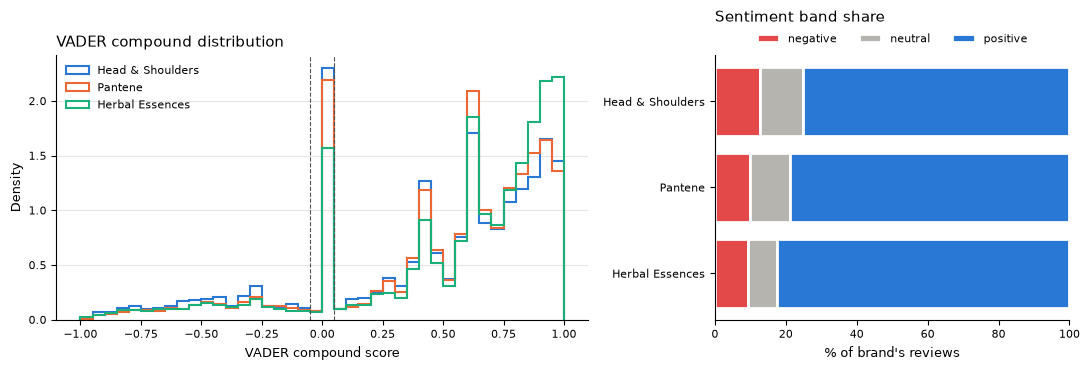

In [6]:
scored = eda.add_sentiment(reviews)
summary = eda.sentiment_summary(scored)
print(summary.round(2))
print("\nmean compound by brand and rating:")
print(eda.compound_by_brand_rating(scored).round(2))

fig, (ax_hist, ax_share) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [3, 2]})
eda.plot_sentiment_distribution(ax_hist, scored)
ax_hist.set_title("VADER compound distribution", loc="left")
eda.plot_sentiment_shares(ax_share, summary)
ax_share.set_title("Sentiment band share", loc="left", pad=24)
fig.tight_layout()
plt.show()

**Takeaway.** Mean VADER compound is highest for Herbal Essences (0.55), then Pantene (0.49) and Head & Shoulders (0.45), which also has the largest negative share (12.9% vs 9.9% and 9.4%). Head & Shoulders scores lowest at every star level (0.55 vs 0.60 and 0.66 at 5★), so the gap is not just rating mix; whether it reflects satisfaction or anti-dandruff vocabulary (itch, flakes) is an interpretation this lexicon heuristic cannot settle.

## Chart 5: Sentiment vs star rating (sanity check)

If VADER tracked satisfaction well, 1–2★ reviews would score negative and 4–5★ positive. Rows sum to 100%.

sentiment_label  negative  neutral  positive
rating                                      
1                    47.9     19.8      32.3
2                    33.6     16.1      50.4
3                    22.1     14.3      63.6
4                     6.5      8.1      85.4
5                     3.6      9.1      87.3

agreement rate (1-2 stars negative, 4-5 stars positive; 3 stars excluded): 80.9%


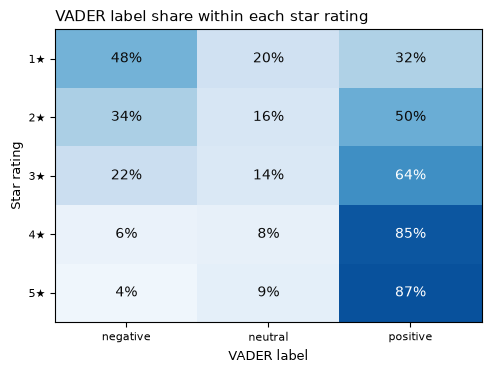

In [7]:
agreement = eda.sentiment_rating_agreement(scored)
print(agreement.round(1))
print(f"\nagreement rate (1-2 stars negative, 4-5 stars positive; 3 stars excluded): "
      f"{eda.agreement_rate(scored):.1f}%")

fig, ax = plt.subplots(figsize=(5.5, 3.8))
eda.plot_agreement(ax, agreement)
ax.set_title("VADER label share within each star rating", loc="left")
plt.show()

In [8]:
# A few short snippets of 1-star reviews that VADER scores positive.
misread = scored[(scored["rating"] == 1) & (scored["sentiment_label"] == "positive")]
for _, row in misread.sample(min(5, len(misread)), random_state=0).iterrows():
    print(f"[{row['sentiment_compound']:+.2f}] {row['review_text'][:120]!r}")

[+0.48] 'I used this shampoo and conditioner 3-4 times a week for about a month. As soon as you use the shampoo and wash it off f'
[+0.23] "If you pay to get it early, don't waste your time or money.  They are not reliable."
[+0.07] "Head and shoulders has always been a mediocre brand for me. This one strangely doesn't lather very well and has a chemic"
[+0.52] 'Thw smell of the product is great however it does not clean my hair.  Even if i just use the shampoo it leaves my hair f'
[+0.36] 'causes tangles. acts like hairspray over detangler'


**Takeaway.** VADER matches the star band on 80.9% of non-3★ reviews, yet only 47.9% of 1★ reviews score negative, while 32.3% of 1★ and 50.4% of 2★ reviews score positive. The snippets show complaints that mention something good ("Thw smell of the product is great however it does not clean my hair") or use no negative words ("causes tangles. acts like hairspray over detangler"), so VADER suits brand-level comparison but not finding individual complaints, which is why filtering by star rating is the safer choice for the RAG layer.

## Chart 6: Top terms in 1–2★ vs 4–5★ reviews per brand

TF-IDF where each (brand × rating band) is one document; 3★ reviews are excluded. Stopwords are scikit-learn's English list plus brand names, generic product words, and filler praise (`config.EDA_EXTRA_STOPWORDS`), so the terms show themes rather than "shampoo" or "pantene". With only six documents, IDF mainly boosts terms unique to one cell, so product-line names can rank high. Mention shares below count each word with an optional plural "s".

Head & Shoulders  low  (15): scalp, dandruff, bottle, smell, dry, work, received, pack, scent, itchy, smells, bottles, bad, selenium, oily
Head & Shoulders  high (15): scalp, symptoms, dandruff, clinical, soother, works, selenium, dry, sulfide, smells, smell, cuero, supreme, scent, itchy
Pantene           low  (15): dry, bottle, lengths, mousse, smell, work, expressions, bottles, formula, left, received, new, spray, greasy, disappointed
Pantene           high (15): expressions, shots, lengths, soft, works, dry, stores, smells, long, nice, price, defy, smell, curly, scent
Herbal Essences   low  (15): smell, bottle, dry, smells, scent, scalp, received, greasy, bottles, left, wash, drama, work, oily, ewg
Herbal Essences   high (15): detoxifying, illuminating, smells, basil, smell, soft, scent, rejuvenating, turkish, dry, lemony, biorenew, nice, works, influenster


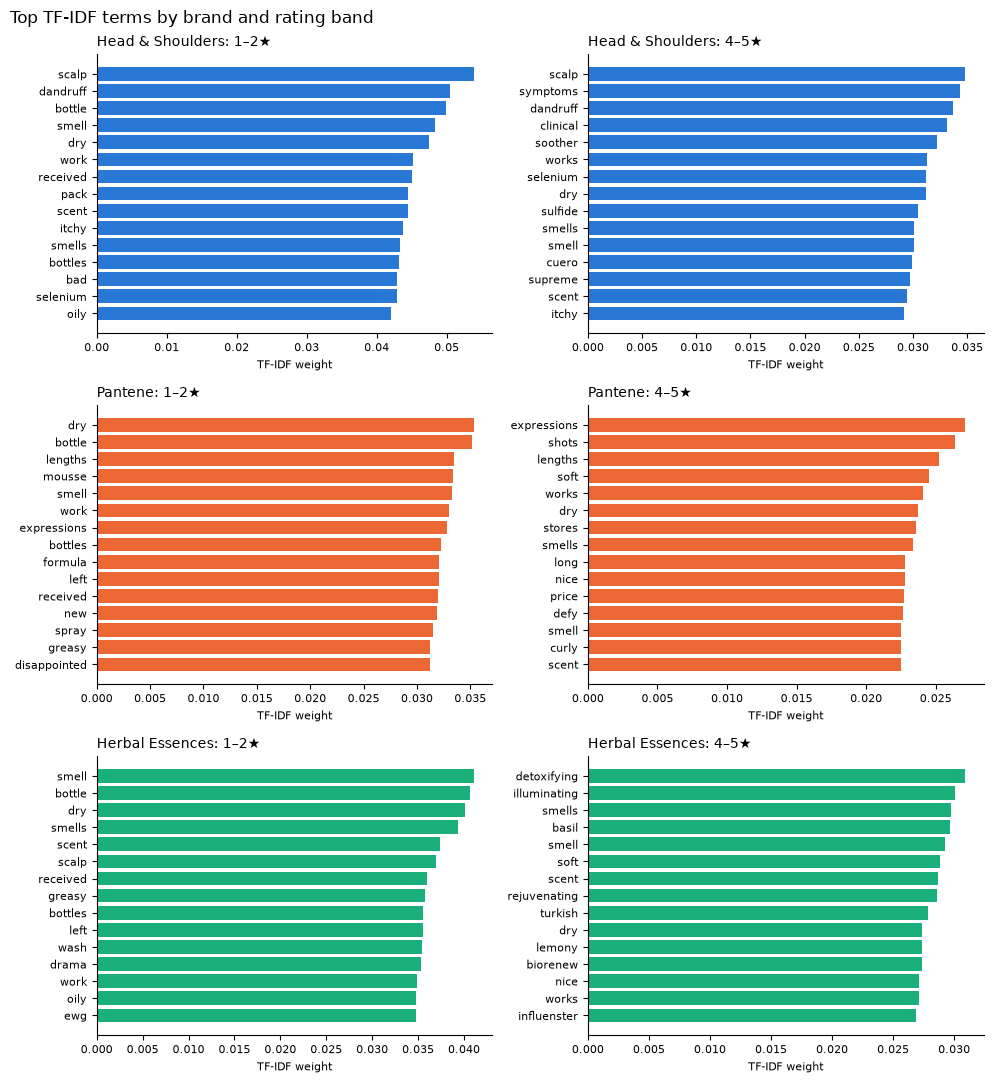

In [9]:
terms = eda.top_terms_by_band(reviews)
for (brand, band), cell in terms.items():
    print(f"{brand:<17} {band:<4} ({len(cell)}): {', '.join(t for t, _ in cell)}")

brands = list(config.BRANDS)
fig, axes = plt.subplots(len(brands), 2, figsize=(10, 11))
for row, brand in enumerate(brands):
    for col, (band, label) in enumerate([("low", "1–2★"), ("high", "4–5★")]):
        eda.plot_top_terms(axes[row, col], terms[(brand, band)], f"{brand}: {label}",
                           color=config.EDA_BRAND_COLORS[brand])
fig.suptitle("Top TF-IDF terms by brand and rating band", x=0.01, ha="left")
fig.tight_layout()
plt.show()

In [10]:
# TF-IDF weights show which words stand out, not how common they are; size a few themes.
words = ["bottle", "received", "itchy", "greasy", "formula", "smell", "influenster"]
for brand in eda.brand_order(reviews):
    print(brand)
    print(eda.term_mention_share(reviews[reviews["brand"] == brand], words).round(1), end="\n\n")

Head & Shoulders


             pct_low  pct_high
term                          
bottle          19.1       6.0
received         9.4       1.2
itchy            6.8       8.8
greasy           5.2       2.2
formula          2.9       1.3
smell           15.1      21.6
influenster      0.0       0.1

Pantene
             pct_low  pct_high
term                          
bottle          14.5       5.0
received         6.1       1.1
itchy            1.6       0.2
greasy           5.3       2.7
formula          4.8       0.9
smell           12.4      14.4
influenster      0.2       0.5

Herbal Essences
             pct_low  pct_high
term                          
bottle          18.1       7.0
received         7.4       4.3
itchy            2.3       0.2
greasy           6.1       3.1
formula          2.3       0.8
smell           24.7      35.5
influenster      1.0       3.1



**Takeaway.** "bottle" and "received" rank in all three brands' 1–2★ term lists, and bottle(s) appears in 14.5–19.1% of each brand's 1–2★ reviews vs 5.0–7.0% of its 4–5★ reviews, the clearest low-band theme printed here. Other signals are smaller or mixed: greasy appears in 5.2–6.1% of 1–2★ reviews for every brand, formula stands out only for Pantene (4.8% low vs 0.9% high), itchy is more common in Head & Shoulders' 4–5★ reviews (8.8%) than its 1–2★ (6.8%), and smell(s) leans toward 4–5★ for every brand (Herbal Essences 35.5% vs 24.7%).

## Insights (running, feeds the README EDA highlights)

- **Ratings are uniformly high and nearly identical across brands.** 65.9–69.4% of reviews are 5★ and 8.3–8.7% are 1★, so star mix barely separates Head & Shoulders, Pantene, and Herbal Essences in this sample.
- **Mean ratings were lower in 2022 than in 2015 for all three brands, by uneven amounts.** Yearly means went 4.49 → 4.06 for Head & Shoulders and 4.44 → 4.13 for Pantene, both drops larger than their monthly standard deviation (0.24, 0.15), but only 4.25 → 4.15 for Herbal Essences, within its 0.19.
- **VADER sentiment is a weak proxy for dissatisfaction.** It matches the star band for 80.9% of non-3★ reviews, yet 32.3% of 1★ and 50.4% of 2★ reviews score positive, which suggests the RAG app should filter complaints by star rating, not sentiment.
- **Packaging is the clearest complaint theme, shared by all three brands.** bottle(s) appears in 14.5–19.1% of each brand's 1–2★ reviews vs 5.0–7.0% of 4–5★; greasiness is also shared (5.2–6.1% of 1–2★), and formula is the one brand-leaning signal found (Pantene, 4.8% of 1–2★).
- **Volume is uneven and may include campaign or incentivized reviews.** It is thin before 2013 and has one-month bursts such as 921 Herbal Essences reviews in March 2015, and 3.1% of Herbal Essences 4–5★ reviews name the incentivized-review programme Influenster, a bias to state in the README limitations.